# TWO-STAGE CLASSIFIER - HUẤN LUYỆN & ĐÁNH GIÁ
Luồng công việc:
1. Nạp dữ liệu đã xử lý từ `preprocessing_data.ipynb` bằng lệnh `%run`.
2. Phân cụm tính chất ảnh **chỉ trên tập train** để tránh rò rỉ dữ liệu.
3. Dùng mô hình phân cụm đã học để **dự đoán** tính chất cho tập test.
4. Tái cấu trúc dữ liệu theo các nhóm tính chất.
5. Huấn luyện các mô hình con và đánh giá pipeline hoàn chỉnh.

## 1. Nạp dữ liệu từ Notebook Tiền xử lý

In [ ]:
# Cell này sẽ thực thi toàn bộ notebook `preprocessing_data.ipynb`.
# Các biến như X_train, y_train_encoded, X_test, y_test_encoded, 
# X_train_hog, X_test_hog, và label_encoder
# sẽ có sẵn trong môi trường của notebook này sau khi chạy xong.

%run preprocessing_data.ipynb

## 2. Phân loại Tính chất ảnh (Chỉ trên Tập Train)

Sử dụng K-Means để tự động nhóm các ảnh có đặc trưng HOG giống nhau vào 3 cụm. Sau đó, chúng ta sẽ kiểm tra và gán nhãn `type1`, `type2`, `type3` cho từng cụm.

Bắt đầu phân cụm K-Means với 3 cụm (types) CHỈ trên tập train...
Phân cụm trên tập train hoàn tất!


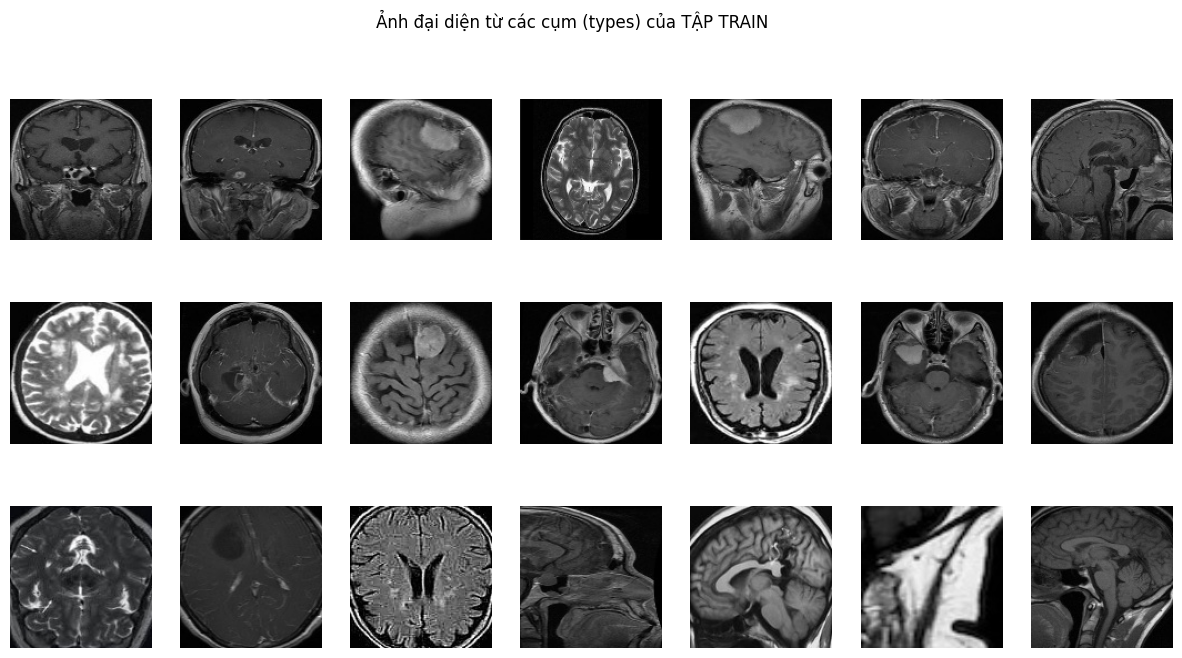


Gán nhãn 'type' cho cả Train và Test hoàn tất.
Các 'type' được sử dụng: ['type1' 'type2' 'type3']


In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import cv2

# --- Bước 2.1: Phân cụm K-Means CHỈ trên tập train ---
N_CLUSTERS = 3 # Số lượng "type" ảnh bạn muốn tìm
kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)

print(f"Bắt đầu phân cụm K-Means với {N_CLUSTERS} cụm (types) CHỈ trên tập train...")
# Huấn luyện và gán nhãn cụm cho tập train
train_type_clusters = kmeans_model.fit_predict(X_train_hog)
print("Phân cụm trên tập train hoàn tất!")

# --- Bước 2.2: Trực quan hóa ---
# Hiển thị ảnh từ tập train để bạn hiểu rõ hơn về từng "type"
fig, axes = plt.subplots(N_CLUSTERS, 7, figsize=(15, N_CLUSTERS * 2.5))
for i in range(N_CLUSTERS):
    cluster_indices = np.where(train_type_clusters == i)[0]
    
    num_samples = min(7, len(cluster_indices))
    if num_samples > 0:
        sample_indices = np.random.choice(cluster_indices, num_samples, replace=False)
        axes[i, 0].set_ylabel(f'Cụm {i}')
        for j, img_idx in enumerate(sample_indices):
            axes[i, j].imshow(cv2.cvtColor(X_train[img_idx], cv2.COLOR_BGR2RGB))
            axes[i, j].axis('off')

plt.suptitle('Ảnh đại diện từ các cụm (types) của TẬP TRAIN')
plt.show()

# --- Bước 2.3: Gán nhãn "type" cho các cụm ---
# Sử dụng tên gọi tổng quát type1, type2, type3
cluster_to_type_map = {
    0: 'type1',
    1: 'type2',
    2: 'type3'
}

# Gán nhãn dạng chữ cho tập train
train_type_labels_str = np.array([cluster_to_type_map[c] for c in train_type_clusters])

# --- Bước 2.4: Dùng model đã fit để DỰ ĐOÁN "type" cho tập test ---
# print("\nDùng mô hình K-Means đã huấn luyện để dự đoán 'type' cho tập test...")
# test_type_clusters = kmeans_model.predict(X_test_hog)
# test_type_labels_str = np.array([cluster_to_type_map[c] for c in test_type_clusters])


# --- Bước 2.5: Mã hóa nhãn "type" ---
type_label_encoder = LabelEncoder()
type_label_encoder.fit(list(cluster_to_type_map.values()))

# Mã hóa nhãn cho cả train và test
y_train_type = type_label_encoder.transform(train_type_labels_str)

# y_test_type = type_label_encoder.transform(test_type_labels_str)

print("\nGán nhãn 'type' cho cả Train và Test hoàn tất.")
print(f"Các 'type' được sử dụng: {type_label_encoder.classes_}")

Trực quan hoá dữ liệu sau khi phân cụm

\nBắt đầu tạo các biểu đồ trực quan hóa cho kết quả phân cụm trên tập train...


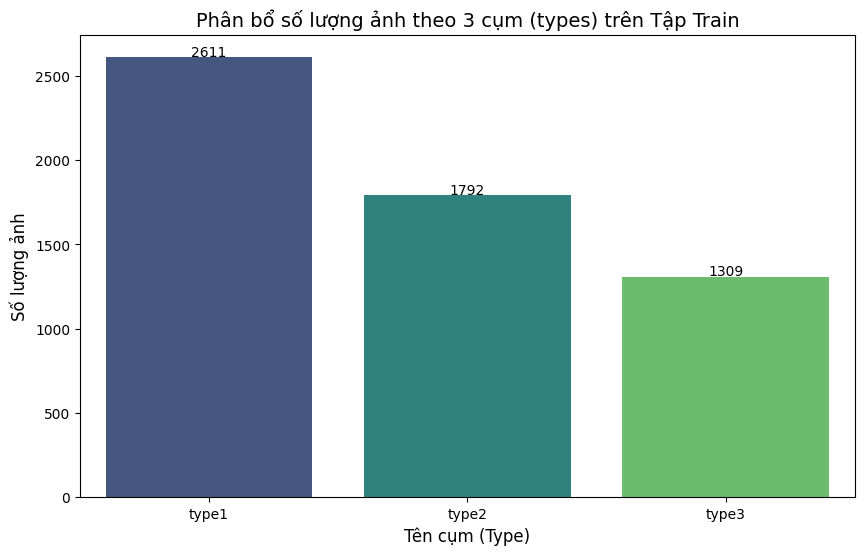

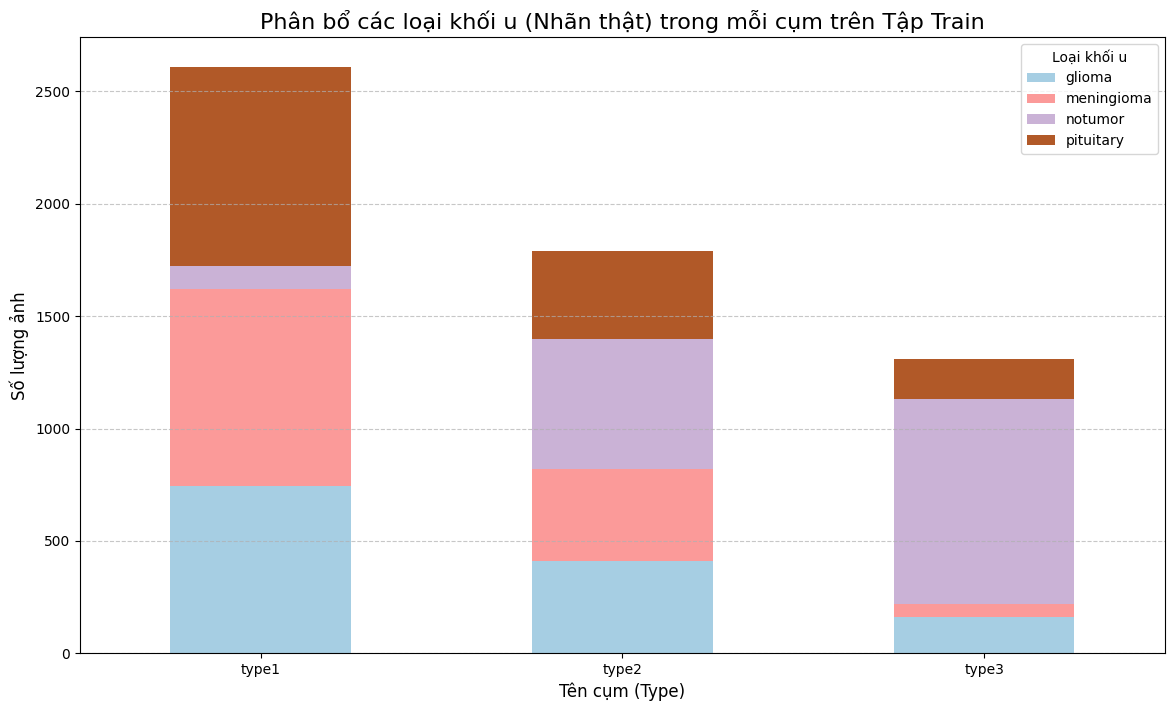

\nĐang vẽ biểu đồ phân tách cụm (Dùng PCA)...
Hoàn tất trực quan hóa!


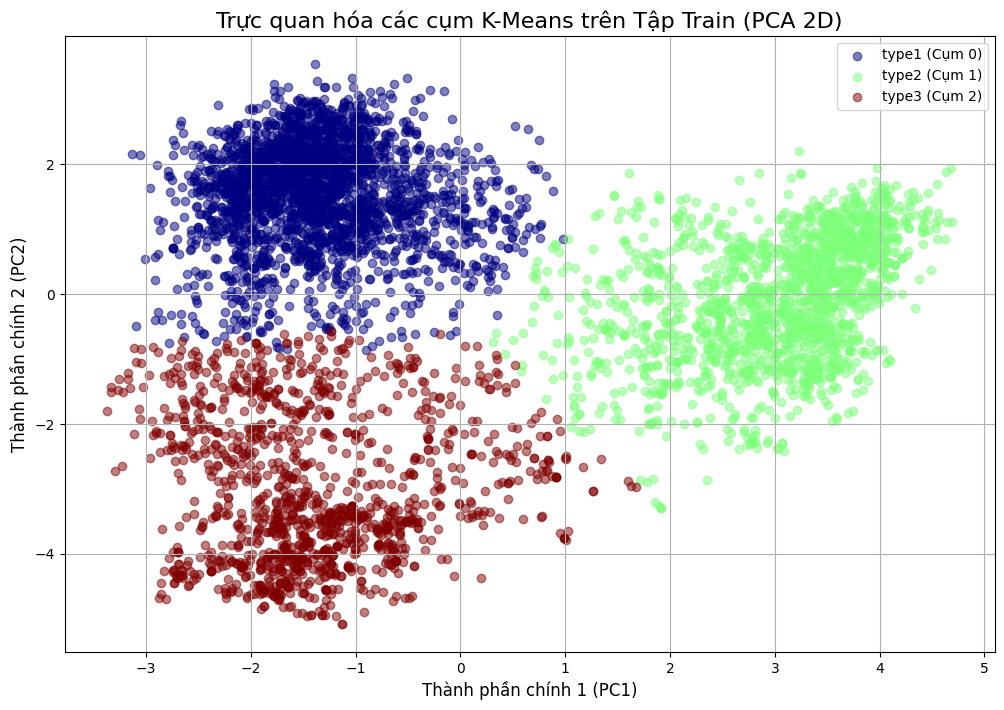

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# =====================================================================
# ## TRỰC QUAN HÓA KẾT QUẢ PHÂN CỤM TRÊN TẬP TRAIN
# =====================================================================

print("\\nBắt đầu tạo các biểu đồ trực quan hóa cho kết quả phân cụm trên tập train...")

# --- BIỂU ĐỒ 1: PHÂN BỔ SỐ LƯỢNG ẢNH TRONG MỖI CỤM (TYPE) ---

# Đếm số lượng ảnh trong mỗi cụm của tập train
cluster_ids, counts = np.unique(train_type_clusters, return_counts=True)

# Lấy tên nhãn (type1, type2,...) từ map
type_names = [cluster_to_type_map.get(id, f'Cụm {id}') for id in cluster_ids]

plt.figure(figsize=(10, 6))
sns.barplot(x=type_names, y=counts, hue=type_names, palette='viridis', legend=False)
plt.title(f'Phân bổ số lượng ảnh theo {N_CLUSTERS} cụm (types) trên Tập Train', fontsize=14)
plt.xlabel('Tên cụm (Type)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)

for index, value in enumerate(counts):
    plt.text(index, value + 5, str(value), ha='center')

plt.show()

# --- BIỂU ĐỒ 2: PHÂN BỔ NHÃN KHỐI U TRONG MỖI CỤM (TYPE) ---

# <<< SỬA ĐỔI Ở ĐÂY >>>
# Sử dụng đúng tên biến y_train_encoded đã được nạp từ notebook preprocessing
df_train_analysis = pd.DataFrame({
    'type_label': train_type_labels_str, # Nhãn type dạng chữ
    'tumor_label': label_encoder.inverse_transform(y_train_encoded) # Nhãn khối u dạng chữ
})

# Đếm số lượng của mỗi loại khối u trong mỗi cụm
count_df = df_train_analysis.groupby(['type_label', 'tumor_label']).size().unstack(fill_value=0)

# Sắp xếp lại các cột theo thứ tự chuẩn
count_df = count_df[label_encoder.classes_]

# Vẽ biểu đồ cột chồng
count_df.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Paired')

plt.title('Phân bổ các loại khối u (Nhãn thật) trong mỗi cụm trên Tập Train', fontsize=16)
plt.xlabel('Tên cụm (Type)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Loại khối u')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- BIỂU ĐỒ 3: TRỰC QUAN HÓA SỰ PHÂN TÁCH CỤM (PCA 2D) ---

print("\\nĐang vẽ biểu đồ phân tách cụm (Dùng PCA)...")

# Giảm chiều dữ liệu HOG của tập train xuống 2D
pca_2d = PCA(n_components=2, random_state=42)
features_2d_train = pca_2d.fit_transform(X_train_hog)

plt.figure(figsize=(12, 8))
colors = plt.get_cmap('jet')(np.linspace(0, 1, N_CLUSTERS))

for i in range(N_CLUSTERS):
    cluster_points = features_2d_train[train_type_clusters == i]
    label_name = cluster_to_type_map.get(i, f'Cụm {i}')
    
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                color=colors[i],
                label=f'{label_name} (Cụm {i})',
                alpha=0.5)

plt.title('Trực quan hóa các cụm K-Means trên Tập Train (PCA 2D)', fontsize=16)
plt.xlabel('Thành phần chính 1 (PC1)', fontsize=12)
plt.ylabel('Thành phần chính 2 (PC2)', fontsize=12)
plt.legend()
plt.grid(True)
print("Hoàn tất trực quan hóa!")
plt.show()

## 3. Tái cấu trúc dữ liệu theo type ảnh

In [4]:
import numpy as np # Đảm bảo numpy đã được import

# =====================================================================
# ## 3. Tái cấu trúc dữ liệu Train theo tính chất (Types)
# =====================================================================

print("Bắt đầu tái cấu trúc DỮ LIỆU TRAIN theo các 'type' đã phân loại...")

# Khởi tạo một dictionary trống, với mỗi key là một tên 'type'
data_by_type = {type_name: {} for type_name in type_label_encoder.classes_}

# Lặp qua từng 'type' đã được mã hóa và tên tương ứng
for i, type_name in enumerate(type_label_encoder.classes_):
    
    # --- Xử lý CHỈ tập Train ---
    # Tạo một "mặt nạ" boolean để lọc ra các chỉ số của ảnh thuộc type này trong tập train
    train_type_mask = (y_train_type == i)
    
    # Sử dụng mask để lấy ra đúng các mẫu dữ liệu từ các biến train lớn
    data_by_type[type_name]['X_train_hog'] = X_train_hog[train_type_mask]
    data_by_type[type_name]['y_train_encoded'] = y_train_encoded[train_type_mask]
    
    # <<< SỬA LỖI Ở ĐÂY: Xóa dòng print cho dữ liệu test >>>
    # In ra thông tin để kiểm tra
    print(f"\nTính chất '{type_name}':")
    print(f"  - Train: {len(data_by_type[type_name]['X_train_hog'])} mẫu")

print("\nHoàn tất tái cấu trúc dữ liệu train. Biến 'data_by_type' đã sẵn sàng.")

Bắt đầu tái cấu trúc DỮ LIỆU TRAIN theo các 'type' đã phân loại...

Tính chất 'type1':
  - Train: 2611 mẫu

Tính chất 'type2':
  - Train: 1792 mẫu

Tính chất 'type3':
  - Train: 1309 mẫu

Hoàn tất tái cấu trúc dữ liệu train. Biến 'data_by_type' đã sẵn sàng.


# III. Huấn luyện các mô hình trên từng type

## 1. Huấn luyện các mô hình

Bây giờ, chúng ta sẽ lặp qua từng type. Với mỗi type, ta áp dụng PCA và LDA riêng, sau đó huấn luyện và đánh giá 2 mô hình Naive Bayes và Logistic Regression.

In [5]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# Khởi tạo dict để lưu các mô hình đã huấn luyện
trained_models = {}
# Lưu lại mô hình kmeans đã fit từ cell trước
trained_models['kmeans'] = kmeans_model 
trained_models['type_label_encoder'] = type_label_encoder

# Lặp qua từng "type" ảnh trong dictionary data_by_type (chỉ chứa dữ liệu train)
for type_name, type_data in data_by_type.items():
    print("\n" + "="*40)
    print(f"HUẤN LUYỆN CHO TÍNH CHẤT (TYPE): {type_name.upper()}")
    print("="*40)

    # Lấy dữ liệu train cục bộ của type hiện tại
    X_train_type_hog = type_data['X_train_hog']
    y_train_type_tumor = type_data['y_train_encoded']
    
    # Kiểm tra nếu có đủ dữ liệu để huấn luyện
    if len(X_train_type_hog) < 5:
        print(f"Bỏ qua type '{type_name}' vì không có đủ dữ liệu train.")
        continue
    
    # Khởi tạo dictionary con để lưu các mô hình của type này
    trained_models[type_name] = {}
    
    # --- A. HUẤN LUYỆN VỚI PCA ---
    print("\n--- Huấn luyện PCA và các mô hình con ---")
    try:
        # 1. Huấn luyện PCA
        pca = PCA(n_components=0.9) 
        X_train_pca = pca.fit_transform(X_train_type_hog)
        trained_models[type_name]['pca'] = pca # Lưu lại bộ giảm chiều PCA
        print(f"Số chiều sau PCA: {X_train_pca.shape[1]}")

        # 2a. Huấn luyện Naive Bayes + PCA
        nb_pca = GaussianNB()
        nb_pca.fit(X_train_pca, y_train_type_tumor)
        trained_models[type_name]['nb_pca'] = nb_pca # Lưu lại mô hình NB_PCA

        # 2b. Huấn luyện Logistic Regression + PCA
        lr_pca = LogisticRegression(max_iter=1000)
        lr_pca.fit(X_train_pca, y_train_type_tumor)
        trained_models[type_name]['lr_pca'] = lr_pca # Lưu lại mô hình LR_PCA
        
        print("Đã huấn luyện xong các mô hình với PCA.")

    except Exception as e:
        print(f"Lỗi khi xử lý PCA cho type '{type_name}': {e}")


    # --- B. HUẤN LUYỆN VỚI LDA ---
    print("\n--- Huấn luyện LDA và các mô hình con ---")
    unique_classes, class_counts = np.unique(y_train_type_tumor, return_counts=True)
    
    if len(unique_classes) <= 1 or np.min(class_counts) < 2:
        print(f"Bỏ qua LDA cho type '{type_name}' vì không đủ mẫu/lớp trong tập train.")
    else:
        # 1. Huấn luyện LDA
        n_components_lda = min(len(unique_classes) - 1, X_train_type_hog.shape[0] - 1)
        lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
        X_train_lda = lda.fit_transform(X_train_type_hog, y_train_type_tumor)
        trained_models[type_name]['lda'] = lda # Lưu lại bộ giảm chiều LDA
        print(f"Số chiều sau LDA: {X_train_lda.shape[1]}")
        
        # 2a. Huấn luyện Naive Bayes + LDA
        nb_lda = GaussianNB()
        nb_lda.fit(X_train_lda, y_train_type_tumor)
        trained_models[type_name]['nb_lda'] = nb_lda # Lưu lại mô hình NB_LDA

        # 2b. Huấn luyện Logistic Regression + LDA
        lr_lda = LogisticRegression(max_iter=1000)
        lr_lda.fit(X_train_lda, y_train_type_tumor)
        trained_models[type_name]['lr_lda'] = lr_lda # Lưu lại mô hình LR_LDA

        print("Đã huấn luyện xong các mô hình với LDA.")

print("\n\n" + "="*50)
print("---> HUẤN LUYỆN TẤT CẢ CÁC MÔ HÌNH CON HOÀN TẤT!")
print("Biến 'trained_models' đã chứa tất cả các thành phần cần thiết cho pipeline.")
print("="*50)


HUẤN LUYỆN CHO TÍNH CHẤT (TYPE): TYPE1

--- Huấn luyện PCA và các mô hình con ---
Số chiều sau PCA: 932
Đã huấn luyện xong các mô hình với PCA.

--- Huấn luyện LDA và các mô hình con ---
Số chiều sau LDA: 3
Đã huấn luyện xong các mô hình với LDA.

HUẤN LUYỆN CHO TÍNH CHẤT (TYPE): TYPE2

--- Huấn luyện PCA và các mô hình con ---
Số chiều sau PCA: 722
Đã huấn luyện xong các mô hình với PCA.

--- Huấn luyện LDA và các mô hình con ---
Số chiều sau LDA: 3
Đã huấn luyện xong các mô hình với LDA.

HUẤN LUYỆN CHO TÍNH CHẤT (TYPE): TYPE3

--- Huấn luyện PCA và các mô hình con ---
Số chiều sau PCA: 554
Đã huấn luyện xong các mô hình với PCA.

--- Huấn luyện LDA và các mô hình con ---
Số chiều sau LDA: 3
Đã huấn luyện xong các mô hình với LDA.


---> HUẤN LUYỆN TẤT CẢ CÁC MÔ HÌNH CON HOÀN TẤT!
Biến 'trained_models' đã chứa tất cả các thành phần cần thiết cho pipeline.


# IV. Dự đoán trên tập test

## 1. Huấn luyện mô hình phân loại type ảnh

Sử dụng toàn bộ dữ liệu HOG và nhãn type ảnh đã tạo để huấn luyện một mô hình chuyên phân loại type ảnh.

In [6]:
# --- Bước 4.1: Huấn luyện mô hình phân loại "Type" ---
# Mô hình này sẽ là bước đầu tiên trong pipeline của chúng ta.
# Nó học cách phân loại "type" dựa trên toàn bộ dữ liệu train.
print("Huấn luyện mô hình Logistic Regression để phân loại 'type' ảnh...")

angle_classifier = LogisticRegression(max_iter=1000)
# Huấn luyện trên X_train_hog và y_train_type đã có từ các cell trên
angle_classifier.fit(X_train_hog, y_train_type)

# Lưu mô hình này vào dictionary chung để tiện quản lý
trained_models['angle_classifier'] = angle_classifier


Huấn luyện mô hình Logistic Regression để phân loại 'type' ảnh...


## 2. Xây dựng pipeline để dự đoán cho tập test

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import numpy as np
import pandas as pd

# =====================================================================
# ## 4. Xây dựng & Đánh giá Pipeline Dự đoán Hoàn chỉnh
# =====================================================================

# --- Bước 4.2: Đánh giá Pipeline 2 bước trên toàn bộ Tập Test ---
print("\nBắt đầu đánh giá pipeline 2 bước trên toàn bộ tập test...")

# Chọn tổ hợp mô hình con bạn muốn sử dụng để đánh giá
# Dựa trên kết quả từ bảng 'results_df', hãy chọn tổ hợp tốt nhất
# Ví dụ: 'pca' và 'lr_pca'
REDUCER_KEY = 'pca'      # Lựa chọn: 'pca' hoặc 'lda'
CLASSIFIER_KEY = 'lr_pca'  # Lựa chọn: 'lr_pca', 'nb_pca', 'lr_lda', 'nb_lda'
print(f"Sử dụng tổ hợp mô hình con: {CLASSIFIER_KEY.replace('_', ' + ').upper()}")

pipeline_predictions = []

# Lặp qua từng mẫu trong TẬP TEST (X_test_hog)
for hog_feature in tqdm(X_test_hog, desc="Đang dự đoán trên tập test"):
    # Dữ liệu đầu vào cần có shape (1, n_features) để predict
    hog_feature_reshaped = hog_feature.reshape(1, -1)
    
    # --- Bước A: Dự đoán "type" của ảnh test ---
    predicted_type_encoded = angle_classifier.predict(hog_feature_reshaped)[0]
    predicted_type_name = type_label_encoder.inverse_transform([predicted_type_encoded])[0]
    
    # Kiểm tra xem mô hình con cho "type" này có tồn tại không 
    # (quan trọng nếu LDA bị bỏ qua ở một số type)
    if predicted_type_name not in trained_models or CLASSIFIER_KEY not in trained_models[predicted_type_name]:
        # Nếu không có mô hình, ta không thể dự đoán. Đánh dấu là lỗi (-1)
        pipeline_predictions.append(-1) 
        continue

    # --- Bước B: Dùng mô hình con tương ứng để dự đoán khối u ---
    reducer = trained_models[predicted_type_name][REDUCER_KEY]
    classifier = trained_models[predicted_type_name][CLASSIFIER_KEY]
    
    # Áp dụng giảm chiều đã được huấn luyện trên tập train của type đó
    feature_reduced = reducer.transform(hog_feature_reshaped)
    
    # Dự đoán loại khối u
    predicted_tumor = classifier.predict(feature_reduced)[0]
    pipeline_predictions.append(predicted_tumor)

pipeline_predictions = np.array(pipeline_predictions)

# --- Bước 4.3: In kết quả cuối cùng ---
# Lọc ra các dự đoán hợp lệ (loại bỏ các trường hợp bị lỗi -1)
valid_indices = (pipeline_predictions != -1)
valid_preds = pipeline_predictions[valid_indices]
# Sử dụng biến y_test_encoded gốc đã được nạp từ đầu
valid_true = y_test_encoded[valid_indices] 

# Tính toán và in kết quả
overall_accuracy = accuracy_score(valid_true, valid_preds)
print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ PIPELINE TRÊN TẬP TEST")
print("="*40)
print(f"\nĐộ chính xác tổng thể của pipeline 2 bước: {overall_accuracy:.4f}")

print("\nBáo cáo chi tiết:")
print(classification_report(valid_true, valid_preds, 
                            target_names=label_encoder.classes_, 
                            labels=np.arange(len(label_encoder.classes_)),
                            zero_division=0))


Bắt đầu đánh giá pipeline 2 bước trên toàn bộ tập test...
Sử dụng tổ hợp mô hình con: LR + PCA


Đang dự đoán trên tập test: 100%|██████████| 1311/1311 [00:06<00:00, 204.03it/s]


KẾT QUẢ ĐÁNH GIÁ PIPELINE TRÊN TẬP TEST

Độ chính xác tổng thể của pipeline 2 bước: 0.8986

Báo cáo chi tiết:
              precision    recall  f1-score   support

      glioma       0.86      0.79      0.82       300
  meningioma       0.83      0.84      0.83       306
     notumor       0.97      0.99      0.98       405
   pituitary       0.91      0.94      0.92       300

    accuracy                           0.90      1311
   macro avg       0.89      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311

